# Module 4: Derivatives — Option Pricing, Greeks & Risk Management
## Aurora Finance | ML-Driven Decision Support

**Objective:** Use NIFTY 50 option chain data to:
1. Reshape intraday option chain from wide to long format
2. Price options with Black-Scholes as a quantitative baseline
3. Build an ML pricing model (XGBoost) and compare accuracy to BS
4. Analyse the implied volatility surface (smile/skew)
5. Compute option Greeks (Delta, Gamma) for hedging
6. Estimate Value-at-Risk (VaR) from intraday NIFTY spot moves
7. Construct a delta-neutral hedge for Aurora's equity portfolio

**Dataset:** `Option_Chain_NSE_intraday_NIFTY_2Feb24.xlsx` — 39,485 rows × 18 columns
- Single trading day: **2 February 2024** (09:20–15:30, 75 time slots × 5-min intervals)
- 6 expiry dates: Feb 8, 15, 22, 29 / Mar 7, Mar 28 2024
- 114 unique strikes: 14,000 – 27,000
- Spot range: 21,816 – 22,123 (NIFTY 50 index)

In [1]:
import subprocess
pkgs = ["xgboost","shap","seaborn","scikit-learn","matplotlib","pandas","numpy","openpyxl","scipy"]
subprocess.run(["pip","install"] + pkgs + ["-q"], check=True)
print("Dependencies ready.")

Dependencies ready.


In [2]:
import pandas as pd
import numpy as np
import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings("ignore")

from scipy.stats import norm
from scipy.optimize import brentq
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from xgboost import XGBRegressor
import shap

plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
RANDOM_STATE   = 42
RISK_FREE_RATE = 0.07      # 7% Indian T-bill proxy (annualised)
TRADING_DAYS   = 252

_nb_dir   = os.path.dirname(os.path.abspath("module4_derivatives.ipynb"))
DATA_FILE = os.path.join(_nb_dir, "Option_Chain_NSE_intraday_NIFTY_2Feb24.xlsx")
print("All libraries imported.")

All libraries imported.


---
## 1. Data Loading & Reshaping — Wide → Long Format

The raw data is **wide format**: one row per (Time, Expiry, Strike) with separate Call and Put columns.
We melt it into **long format**: one row per option contract (Call or Put).

In [3]:
raw = pd.read_excel(DATA_FILE)
raw["Time"]   = pd.to_datetime(raw["Time"])
raw["Expiry"] = pd.to_datetime(raw["Expiry"])
print(f"Raw shape : {raw.shape}")
print(f"Columns   : {list(raw.columns)}")
print(f"Time range: {raw['Time'].min()} to {raw['Time'].max()}")
print(f"Expiries  : {sorted(raw['Expiry'].dt.date.unique())}")
print(f"Strikes   : {raw['Strike'].min()} – {raw['Strike'].max()} ({raw['Strike'].nunique()} unique)")
display(raw.head(3))

Raw shape : (39485, 18)
Columns   : ['Time', 'Spot', 'Expiry', 'Call_Traded_Qty', 'Call IV', 'Call Bid', 'Call Ask', 'Call Bid_Qty', 'Call Ask_Qty', 'Call LTP', 'Strike', 'Put Bid', 'Put Ask', 'Put Bid_Qty', 'Put Ask_Qty', 'Put LTP', 'Put IV', 'Put_Traded_Qty']
Time range: 2024-02-02 09:20:00 to 2024-02-02 15:30:00
Expiries  : [datetime.date(2024, 2, 8), datetime.date(2024, 2, 15), datetime.date(2024, 2, 22), datetime.date(2024, 2, 29), datetime.date(2024, 3, 7), datetime.date(2024, 3, 28)]
Strikes   : 14000 – 27000 (114 unique)


,Time,Spot,Expiry,Call_Traded_Qty,Call IV,Call Bid,Call Ask,Call Bid_Qty,Call Ask_Qty,Call LTP,Strike,Put Bid,Put Ask,Put Bid_Qty,Put Ask_Qty,Put LTP,Put IV,Put_Traded_Qty
0,2024-02-02 09:20:00,21874.4,2024-02-08,0,0.0,2173.2,2656.20,150,100,0.0,19500,1.35,1.4,21350,67650,1.40,35.16,4297
1,2024-02-02 09:25:00,21935.7,2024-02-08,0,0.0,2218.9,2612.30,1500,1500,0.0,19500,1.35,1.4,21300,47250,1.35,35.64,10098
2,2024-02-02 09:30:00,21942.5,2024-02-08,0,0.0,2231.1,2601.25,1500,1000,0.0,19500,1.35,1.4,66600,33500,1.40,35.89,13128


In [4]:
# Melt wide → long: separate Call and Put rows
calls = raw[["Time","Spot","Expiry","Strike",
             "Call LTP","Call Bid","Call Ask","Call IV","Call_Traded_Qty"]].copy()
calls.columns = ["Time","Spot","Expiry","Strike","LTP","Bid","Ask","IV","Traded_Qty"]
calls["Type"] = "Call"

puts = raw[["Time","Spot","Expiry","Strike",
            "Put LTP","Put Bid","Put Ask","Put IV","Put_Traded_Qty"]].copy()
puts.columns = ["Time","Spot","Expiry","Strike","LTP","Bid","Ask","IV","Traded_Qty"]
puts["Type"] = "Put"

options = pd.concat([calls, puts], ignore_index=True)

# Derived columns
options["Mid_Price"]      = (options["Bid"] + options["Ask"]) / 2
options["Ref_Price"]      = np.where(options["LTP"] > 0, options["LTP"], options["Mid_Price"])
options["Moneyness"]      = options["Spot"] / options["Strike"]   # >1 = ITM for Call
options["Log_Moneyness"]  = np.log(options["Spot"] / options["Strike"])

# Time to expiry in years
trade_date = pd.Timestamp("2024-02-02")
options["TTE_days"] = (options["Expiry"] - trade_date).dt.days
options["TTE_years"]= options["TTE_days"] / 365.0

# Intraday time index (minutes from open 09:20)
market_open = pd.Timestamp("2024-02-02 09:20:00")
options["Min_from_open"] = (options["Time"] - market_open).dt.total_seconds() / 60

print(f"Long-format shape: {options.shape}")
print(f"Call rows: {(options.Type=='Call').sum():,} | Put rows: {(options.Put=='Put').sum() if False else (options.Type=='Put').sum():,}")
display(options.head(3))

Long-format shape: (78970, 17)
Call rows: 39,485 | Put rows: 39,485


,Time,Spot,Expiry,Strike,LTP,Bid,Ask,IV,Traded_Qty,Type,Mid_Price,Ref_Price,Moneyness,Log_Moneyness,TTE_days,TTE_years,Min_from_open
0,2024-02-02 09:20:00,21874.4,2024-02-08,19500,0.0,2173.2,2656.20,0.0,0,Call,2414.700,2414.700,1.121764,0.114903,6,0.016438,0.0
1,2024-02-02 09:25:00,21935.7,2024-02-08,19500,0.0,2218.9,2612.30,0.0,0,Call,2415.600,2415.600,1.124908,0.117701,6,0.016438,5.0
2,2024-02-02 09:30:00,21942.5,2024-02-08,19500,0.0,2231.1,2601.25,0.0,0,Call,2416.175,2416.175,1.125256,0.118011,6,0.016438,10.0


In [5]:
# Filter to near-the-money contracts (within 10% of spot) with valid prices
# and positive TTE — this removes deep OTM noise and expired contracts
ntm_mask = (
    (abs(options["Log_Moneyness"]) < 0.10) &  # within ~10% of spot
    (options["TTE_years"] > 0) &
    (options["Ref_Price"] > 0) &
    (options["IV"] > 0)
)
opt_ntm = options[ntm_mask].copy().reset_index(drop=True)

print(f"Near-the-money (NTM) contracts: {len(opt_ntm):,} rows")
print(f"  Calls: {(opt_ntm.Type=='Call').sum():,} | Puts: {(opt_ntm.Type=='Put').sum():,}")
print(f"  Expiries in NTM set: {sorted(opt_ntm['TTE_days'].unique())}")
print(f"  Strike range (NTM): {opt_ntm['Strike'].min()} – {opt_ntm['Strike'].max()}")
print(f"  IV range           : {opt_ntm['IV'].min():.1f}% – {opt_ntm['IV'].max():.1f}%")

Near-the-money (NTM) contracts: 38,481 rows
  Calls: 19,332 | Puts: 19,149
  Expiries in NTM set: [np.int64(6), np.int64(13), np.int64(20), np.int64(27), np.int64(34), np.int64(55)]
  Strike range (NTM): 19750 – 24000
  IV range           : 4.1% – 83.2%


---
## 2. Exploratory Data Analysis

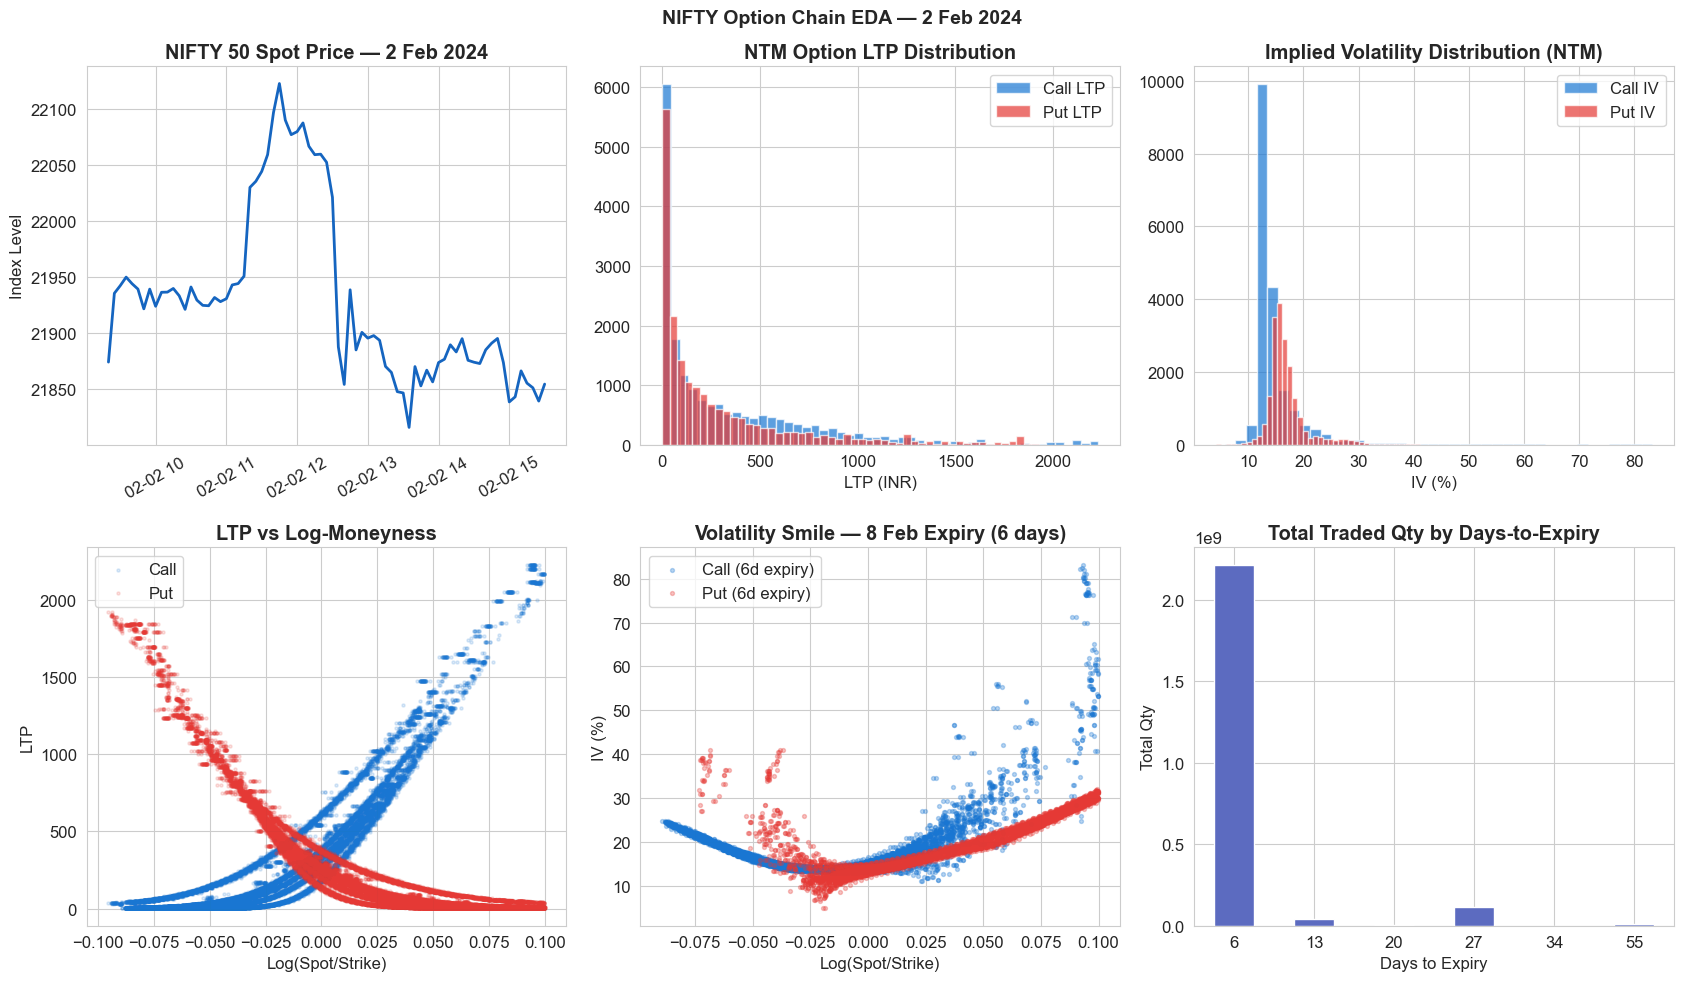

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# (0,0) Spot price over day
t_grp = raw.groupby("Time")["Spot"].mean()
axes[0,0].plot(t_grp.index, t_grp.values, color="#1565C0", lw=2)
axes[0,0].set_title("NIFTY 50 Spot Price — 2 Feb 2024", fontweight="bold")
axes[0,0].set_ylabel("Index Level"); axes[0,0].tick_params(axis="x", rotation=30)

# (0,1) Call vs Put LTP distribution (NTM)
axes[0,1].hist(opt_ntm[opt_ntm.Type=="Call"]["LTP"], bins=50, alpha=0.7,
               color="#1976D2", label="Call LTP", edgecolor="white")
axes[0,1].hist(opt_ntm[opt_ntm.Type=="Put"]["LTP"],  bins=50, alpha=0.7,
               color="#E53935", label="Put LTP",  edgecolor="white")
axes[0,1].set_title("NTM Option LTP Distribution", fontweight="bold")
axes[0,1].set_xlabel("LTP (INR)"); axes[0,1].legend()

# (0,2) IV distribution by type
axes[0,2].hist(opt_ntm[opt_ntm.Type=="Call"]["IV"], bins=40, alpha=0.7,
               color="#1976D2", label="Call IV", edgecolor="white")
axes[0,2].hist(opt_ntm[opt_ntm.Type=="Put"]["IV"],  bins=40, alpha=0.7,
               color="#E53935", label="Put IV",  edgecolor="white")
axes[0,2].set_title("Implied Volatility Distribution (NTM)", fontweight="bold")
axes[0,2].set_xlabel("IV (%)"); axes[0,2].legend()

# (1,0) LTP vs Moneyness
for otype, color in [("Call","#1976D2"),("Put","#E53935")]:
    sub = opt_ntm[opt_ntm.Type==otype]
    axes[1,0].scatter(sub["Log_Moneyness"], sub["LTP"], alpha=0.15, s=5,
                      color=color, label=otype)
axes[1,0].set_title("LTP vs Log-Moneyness", fontweight="bold")
axes[1,0].set_xlabel("Log(Spot/Strike)"); axes[1,0].set_ylabel("LTP")
axes[1,0].legend()

# (1,1) IV vs Log-Moneyness (vol smile)
for otype, color in [("Call","#1976D2"),("Put","#E53935")]:
    sub = opt_ntm[(opt_ntm.Type==otype) & (opt_ntm.TTE_days==6)]
    axes[1,1].scatter(sub["Log_Moneyness"], sub["IV"], alpha=0.3, s=8,
                      color=color, label=f"{otype} (6d expiry)")
axes[1,1].set_title("Volatility Smile — 8 Feb Expiry (6 days)", fontweight="bold")
axes[1,1].set_xlabel("Log(Spot/Strike)"); axes[1,1].set_ylabel("IV (%)")
axes[1,1].legend()

# (1,2) Volume by expiry
vol_by_exp = options.groupby("TTE_days")["Traded_Qty"].sum()
vol_by_exp.plot(kind="bar", ax=axes[1,2], color="#5C6BC0", edgecolor="white")
axes[1,2].set_title("Total Traded Qty by Days-to-Expiry", fontweight="bold")
axes[1,2].set_xlabel("Days to Expiry"); axes[1,2].set_ylabel("Total Qty")
axes[1,2].tick_params(axis="x", rotation=0)

plt.suptitle("NIFTY Option Chain EDA — 2 Feb 2024", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "option_eda.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Black-Scholes Baseline Pricing

The **Black-Scholes** formula prices a European option given:
- **S** — spot price, **K** — strike, **T** — time to expiry (years)
- **r** — risk-free rate (7%), **σ** — implied volatility (from market IV column)

$$C = S \cdot N(d_1) - K e^{-rT} N(d_2)$$
$$P = K e^{-rT} N(-d_2) - S \cdot N(-d_1)$$
$$d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

We use the **market IV** as σ input — so BS should closely track market prices near-the-money.
The residual (BS Price − Market LTP) reveals where BS fails.

In [7]:
def bs_price(S, K, T, r, sigma, option_type="Call"):
    """Black-Scholes option price."""
    if T <= 0 or sigma <= 0:
        intrinsic = max(S - K, 0) if option_type == "Call" else max(K - S, 0)
        return intrinsic
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "Call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def bs_delta(S, K, T, r, sigma, option_type="Call"):
    """Black-Scholes Delta."""
    if T <= 0 or sigma <= 0:
        return 1.0 if (option_type=="Call" and S>K) else 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1) if option_type == "Call" else norm.cdf(d1) - 1

def bs_gamma(S, K, T, r, sigma):
    """Black-Scholes Gamma (same for Call and Put)."""
    if T <= 0 or sigma <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_vega(S, K, T, r, sigma):
    """Black-Scholes Vega (per 1% move in vol)."""
    if T <= 0 or sigma <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T) * 0.01

print("Black-Scholes functions defined.")
# Quick sanity check
test_price = bs_price(22000, 22000, 6/365, 0.07, 0.15, "Call")
print(f"BS sanity check — ATM Call (S=22000, K=22000, T=6d, IV=15%): {test_price:.2f}")

Black-Scholes functions defined.
BS sanity check — ATM Call (S=22000, K=22000, T=6d, IV=15%): 181.64


In [8]:
# Compute BS price for all NTM contracts using market IV as sigma
sigma_input = opt_ntm["IV"].values / 100.0   # IV in % → decimal

bs_prices = np.array([
    bs_price(row["Spot"], row["Strike"], row["TTE_years"],
             RISK_FREE_RATE, sig, row["Type"])
    for (_, row), sig in zip(opt_ntm.iterrows(), sigma_input)
])

opt_ntm = opt_ntm.copy()
opt_ntm["BS_Price"]   = bs_prices
opt_ntm["BS_Residual"]= opt_ntm["BS_Price"] - opt_ntm["LTP"]  # BS minus market
opt_ntm["Abs_Error"]  = opt_ntm["BS_Residual"].abs()

# Overall BS accuracy
bs_rmse = np.sqrt(mean_squared_error(opt_ntm["LTP"], opt_ntm["BS_Price"]))
bs_mae  = mean_absolute_error(opt_ntm["LTP"], opt_ntm["BS_Price"])
bs_r2   = r2_score(opt_ntm["LTP"], opt_ntm["BS_Price"])

print("=== Black-Scholes Baseline (using market IV as sigma) ===")
print(f"  RMSE : {bs_rmse:.2f} INR")
print(f"  MAE  : {bs_mae:.2f} INR")
print(f"  R²   : {bs_r2:.4f}")
print(f"  Mean BS Residual: {opt_ntm['BS_Residual'].mean():.2f} (positive = BS overprices)")

=== Black-Scholes Baseline (using market IV as sigma) ===
  RMSE : 29.57 INR
  MAE  : 19.05 INR
  R²   : 0.9947
  Mean BS Residual: 0.31 (positive = BS overprices)


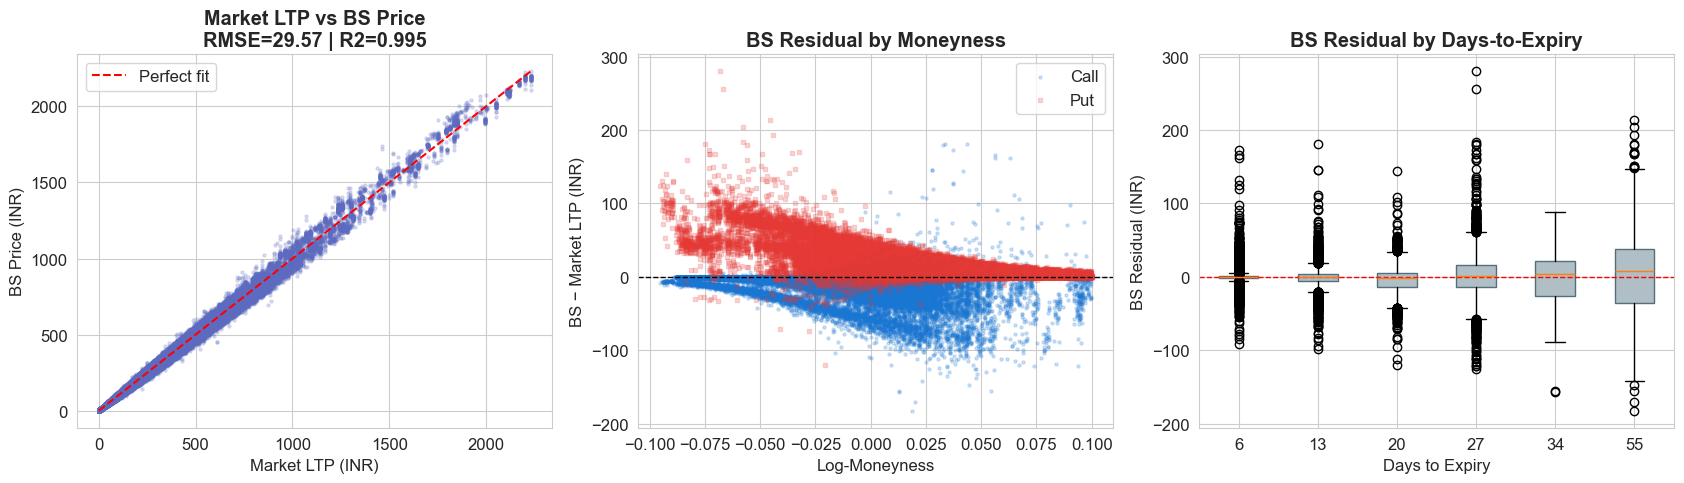

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Actual vs BS
axes[0].scatter(opt_ntm["LTP"], opt_ntm["BS_Price"], alpha=0.2, s=5, color="#5C6BC0")
lim = max(opt_ntm["LTP"].max(), opt_ntm["BS_Price"].max())
axes[0].plot([0, lim], [0, lim], "r--", lw=1.5, label="Perfect fit")
axes[0].set_xlabel("Market LTP (INR)"); axes[0].set_ylabel("BS Price (INR)")
axes[0].set_title(f"Market LTP vs BS Price\nRMSE={bs_rmse:.2f} | R2={bs_r2:.3f}", fontweight="bold")
axes[0].legend()

# Residual by moneyness
for otype, color, marker in [("Call","#1976D2","o"),("Put","#E53935","s")]:
    sub = opt_ntm[opt_ntm.Type==otype]
    axes[1].scatter(sub["Log_Moneyness"], sub["BS_Residual"], alpha=0.2, s=5,
                    color=color, marker=marker, label=otype)
axes[1].axhline(0, color="black", lw=1, linestyle="--")
axes[1].set_xlabel("Log-Moneyness"); axes[1].set_ylabel("BS − Market LTP (INR)")
axes[1].set_title("BS Residual by Moneyness", fontweight="bold")
axes[1].legend()

# Residual by TTE
axes[2].boxplot([opt_ntm[opt_ntm.TTE_days==d]["BS_Residual"].values
                 for d in sorted(opt_ntm["TTE_days"].unique())],
                labels=sorted(opt_ntm["TTE_days"].unique()), patch_artist=True,
                boxprops=dict(facecolor="#B0BEC5", color="#546E7A"))
axes[2].axhline(0, color="red", lw=1, linestyle="--")
axes[2].set_xlabel("Days to Expiry"); axes[2].set_ylabel("BS Residual (INR)")
axes[2].set_title("BS Residual by Days-to-Expiry", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "bs_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 4. ML Option Pricing — Feature Engineering & Model Comparison

**Goal:** Can ML beat Black-Scholes at pricing options?

**Feature sets:**
- **Set A (structural):** Log-Moneyness, TTE_years, IV, option Type indicator
- **Set B (+ market microstructure):** Set A + Spot, Bid-Ask spread, Min_from_open, Traded_Qty_log

**Models:** Linear Regression, Ridge, Random Forest, XGBoost, Gradient Boosting
**Validation:** 5-fold KFold (time shuffled — intraday prices cluster, fold shuffle breaks autocorrelation bias)

In [10]:
opt_ntm = opt_ntm.copy()

# Feature engineering
opt_ntm["Is_Call"]        = (opt_ntm["Type"] == "Call").astype(int)
opt_ntm["BA_Spread"]      = opt_ntm["Ask"] - opt_ntm["Bid"]
opt_ntm["BA_Spread_Pct"]  = opt_ntm["BA_Spread"] / (opt_ntm["Mid_Price"] + 1e-6)
opt_ntm["Log_Traded_Qty"] = np.log1p(opt_ntm["Traded_Qty"])
opt_ntm["IV_x_TTE"]       = opt_ntm["IV"] * opt_ntm["TTE_years"]   # interaction

# Intrinsic value (floor)
opt_ntm["Intrinsic"] = np.where(
    opt_ntm["Type"]=="Call",
    np.maximum(opt_ntm["Spot"] - opt_ntm["Strike"], 0),
    np.maximum(opt_ntm["Strike"] - opt_ntm["Spot"], 0)
)

SET_A = ["Log_Moneyness","TTE_years","IV","Is_Call","Intrinsic"]
SET_B = SET_A + ["Spot","BA_Spread_Pct","Min_from_open","Log_Traded_Qty","IV_x_TTE"]

TARGET = "LTP"
y = opt_ntm[TARGET].values

print(f"Feature Set A: {SET_A}")
print(f"Feature Set B: {SET_B}")
print(f"Samples for ML: {len(opt_ntm):,}")

Feature Set A: ['Log_Moneyness', 'TTE_years', 'IV', 'Is_Call', 'Intrinsic']
Feature Set B: ['Log_Moneyness', 'TTE_years', 'IV', 'Is_Call', 'Intrinsic', 'Spot', 'BA_Spread_Pct', 'Min_from_open', 'Log_Traded_Qty', 'IV_x_TTE']
Samples for ML: 38,481


In [11]:
def eval_models_cv(models, X, y, n_splits=5, label=""):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    results = []
    for name, model in models.items():
        rmses, maes, r2s = [], [], []
        for tr, te in kf.split(X):
            m = clone(model)
            m.fit(X[tr], y[tr])
            pred = m.predict(X[te])
            rmses.append(np.sqrt(mean_squared_error(y[te], pred)))
            maes.append(mean_absolute_error(y[te], pred))
            r2s.append(r2_score(y[te], pred))
        results.append({
            "Model":  name,
            "RMSE":   f"{np.mean(rmses):.2f} +/- {np.std(rmses):.2f}",
            "MAE":    f"{np.mean(maes):.2f} +/- {np.std(maes):.2f}",
            "R2":     f"{np.mean(r2s):.4f} +/- {np.std(r2s):.4f}",
            "_rmse":  np.mean(rmses),
            "_r2":    np.mean(r2s),
        })
    df_r = pd.DataFrame(results).sort_values("_rmse")
    print(f"\n{label}")
    display(df_r.drop(columns=["_rmse","_r2"]).reset_index(drop=True))
    return df_r

ml_models = {
    "Linear Regression": LinearRegression(),
    "Ridge":             Ridge(alpha=1.0),
    "Random Forest":     RandomForestRegressor(n_estimators=200, max_depth=8,
                                                n_jobs=-1, random_state=RANDOM_STATE),
    "XGBoost":           XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                                       subsample=0.8, colsample_bytree=0.8,
                                       random_state=RANDOM_STATE, verbosity=0),
    "GradientBoosting":  GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                    max_depth=4, random_state=RANDOM_STATE),
}

X_A = opt_ntm[SET_A].values
X_B = opt_ntm[SET_B].values

res_A = eval_models_cv(ml_models, X_A, y, label="Set A — Structural Features")
res_B = eval_models_cv(ml_models, X_B, y, label="Set B — + Microstructure Features")

# Black-Scholes comparison row
print(f"\nBlack-Scholes baseline — RMSE: {bs_rmse:.2f} | MAE: {bs_mae:.2f} | R2: {bs_r2:.4f}")


Set A — Structural Features


,Model,RMSE,MAE,R2
0,XGBoost,14.16 +/- 0.48,8.26 +/- 0.06,0.9988 +/- 0.0001
1,GradientBoosting,18.07 +/- 0.54,11.50 +/- 0.22,0.9980 +/- 0.0001
2,Random Forest,26.89 +/- 0.78,16.38 +/- 0.33,0.9956 +/- 0.0003
3,Linear Regression,100.85 +/- 0.83,80.07 +/- 0.43,0.9383 +/- 0.0015
4,Ridge,100.86 +/- 0.84,80.07 +/- 0.44,0.9383 +/- 0.0015



Set B — + Microstructure Features


,Model,RMSE,MAE,R2
0,XGBoost,15.15 +/- 0.49,9.61 +/- 0.22,0.9986 +/- 0.0001
1,GradientBoosting,17.51 +/- 0.41,11.03 +/- 0.16,0.9981 +/- 0.0001
2,Random Forest,25.44 +/- 0.74,15.75 +/- 0.29,0.9961 +/- 0.0003
3,Linear Regression,99.68 +/- 0.78,79.02 +/- 0.41,0.9398 +/- 0.0016
4,Ridge,99.89 +/- 0.83,79.28 +/- 0.45,0.9395 +/- 0.0016



Black-Scholes baseline — RMSE: 29.57 | MAE: 19.05 | R2: 0.9947


ML (XGBoost Set B) full-data fit — RMSE: 13.09 | MAE: 8.70 | R2: 0.9990


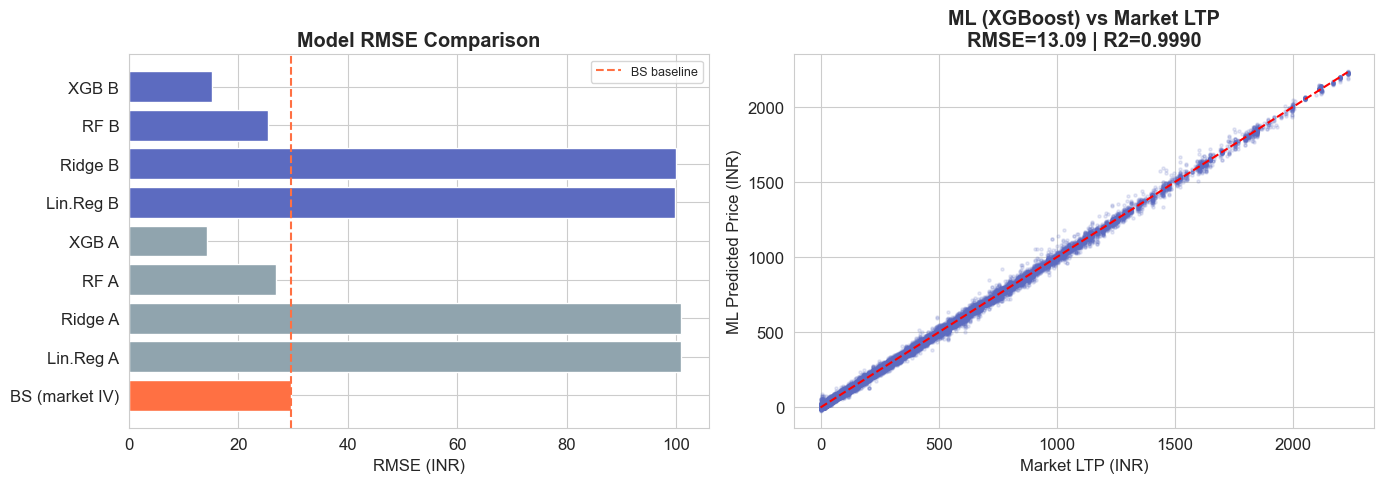

In [12]:
# Train best model (XGBoost, Set B) on full data for downstream use
best_ml = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                        subsample=0.8, colsample_bytree=0.8,
                        random_state=RANDOM_STATE, verbosity=0)
best_ml.fit(opt_ntm[SET_B], y)
opt_ntm = opt_ntm.copy()
opt_ntm["ML_Price"] = best_ml.predict(opt_ntm[SET_B])
opt_ntm["ML_Error"] = opt_ntm["ML_Price"] - opt_ntm["LTP"]

ml_rmse = np.sqrt(mean_squared_error(opt_ntm["LTP"], opt_ntm["ML_Price"]))
ml_mae  = mean_absolute_error(opt_ntm["LTP"], opt_ntm["ML_Price"])
ml_r2   = r2_score(opt_ntm["LTP"], opt_ntm["ML_Price"])

print(f"ML (XGBoost Set B) full-data fit — RMSE: {ml_rmse:.2f} | MAE: {ml_mae:.2f} | R2: {ml_r2:.4f}")

# Summary comparison chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods  = ["BS (market IV)","Lin.Reg A","Ridge A","RF A","XGB A",
            "Lin.Reg B","Ridge B","RF B","XGB B"]
rmse_vals = [bs_rmse,
             res_A[res_A.Model=="Linear Regression"]["_rmse"].values[0],
             res_A[res_A.Model=="Ridge"]["_rmse"].values[0],
             res_A[res_A.Model=="Random Forest"]["_rmse"].values[0],
             res_A[res_A.Model=="XGBoost"]["_rmse"].values[0],
             res_B[res_B.Model=="Linear Regression"]["_rmse"].values[0],
             res_B[res_B.Model=="Ridge"]["_rmse"].values[0],
             res_B[res_B.Model=="Random Forest"]["_rmse"].values[0],
             res_B[res_B.Model=="XGBoost"]["_rmse"].values[0]]
colors_bar = ["#FF7043"] + ["#90A4AE"]*4 + ["#5C6BC0"]*4
axes[0].barh(methods, rmse_vals, color=colors_bar, edgecolor="white")
axes[0].axvline(bs_rmse, color="#FF7043", linestyle="--", lw=1.5, label="BS baseline")
axes[0].set_xlabel("RMSE (INR)"); axes[0].set_title("Model RMSE Comparison", fontweight="bold")
axes[0].legend(fontsize=9)

# Actual vs ML
axes[1].scatter(opt_ntm["LTP"], opt_ntm["ML_Price"], alpha=0.15, s=5, color="#5C6BC0")
lim2 = opt_ntm["LTP"].max()
axes[1].plot([0,lim2],[0,lim2],"r--",lw=1.5)
axes[1].set_xlabel("Market LTP (INR)"); axes[1].set_ylabel("ML Predicted Price (INR)")
axes[1].set_title(f"ML (XGBoost) vs Market LTP\nRMSE={ml_rmse:.2f} | R2={ml_r2:.4f}", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "ml_pricing.png"), dpi=150, bbox_inches="tight")
plt.show()

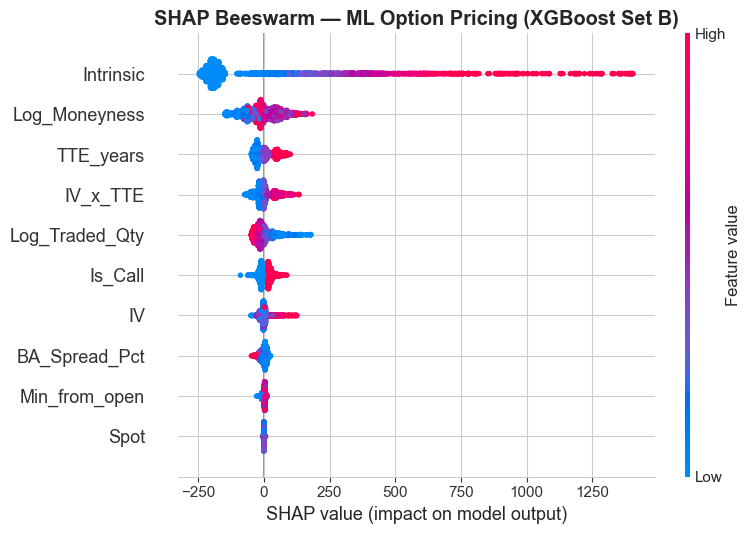

In [13]:
# SHAP analysis
sample_idx = np.random.RandomState(42).choice(len(opt_ntm), size=min(3000, len(opt_ntm)), replace=False)
X_shap = opt_ntm[SET_B].iloc[sample_idx]

explainer_ml = shap.TreeExplainer(best_ml)
shap_vals    = explainer_ml.shap_values(X_shap)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_shap, feature_names=SET_B, show=False)
plt.title("SHAP Beeswarm — ML Option Pricing (XGBoost Set B)", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "shap_options.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Implied Volatility Surface — Smile & Skew

The **volatility smile** plots IV vs strike/moneyness for a fixed expiry.
The **IV surface** extends this across all expiries — showing how IV varies by both strike and time.

Key observations to look for:
- **Smile** (symmetric U-shape): both OTM calls and puts are expensive relative to ATM
- **Skew** (left-skewed): OTM puts have higher IV than OTM calls — fear of downside crash
- **Term structure**: short-dated options often have higher IV due to event risk

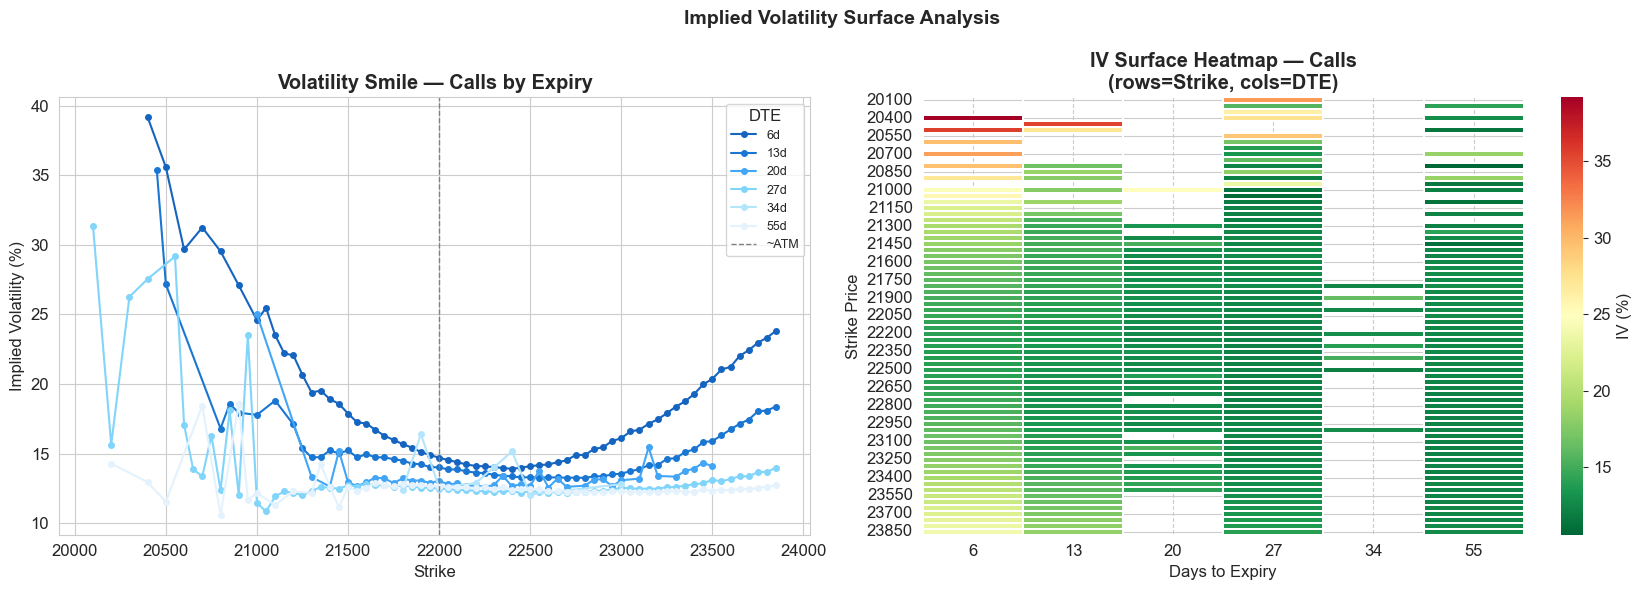

In [14]:
# Aggregate IV to a clean surface: median IV per (TTE_days, Strike) per option type
iv_surface_calls = (opt_ntm[opt_ntm.Type=="Call"]
                    .groupby(["TTE_days","Strike"])["IV"]
                    .median().reset_index())
iv_surface_puts  = (opt_ntm[opt_ntm.Type=="Put"]
                    .groupby(["TTE_days","Strike"])["IV"]
                    .median().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Volatility smile per expiry (calls)
colors_exp = ["#1565C0","#1976D2","#42A5F5","#81D4FA","#B3E5FC","#E3F2FD"]
for (tte, grp), color in zip(iv_surface_calls.groupby("TTE_days"), colors_exp):
    grp_ntm = grp[abs(grp["Strike"] - 22000) < 2000]
    if len(grp_ntm) > 2:
        axes[0].plot(grp_ntm["Strike"], grp_ntm["IV"], marker="o", ms=4,
                     label=f"{int(tte)}d", color=color, lw=1.5)
axes[0].axvline(22000, color="gray", linestyle="--", lw=1, label="~ATM")
axes[0].set_title("Volatility Smile — Calls by Expiry", fontweight="bold")
axes[0].set_xlabel("Strike"); axes[0].set_ylabel("Implied Volatility (%)")
axes[0].legend(title="DTE", fontsize=9)

# IV surface heatmap (calls, pivot)
iv_pivot = iv_surface_calls.pivot_table(index="Strike", columns="TTE_days", values="IV")
# Focus on NTM strikes only
mid_spot  = 22000
iv_pivot  = iv_pivot.loc[abs(iv_pivot.index - mid_spot) < 2000]
sns.heatmap(iv_pivot, ax=axes[1], cmap="RdYlGn_r", annot=False,
            cbar_kws={"label":"IV (%)"}, linewidths=0.1)
axes[1].set_title("IV Surface Heatmap — Calls\n(rows=Strike, cols=DTE)", fontweight="bold")
axes[1].set_xlabel("Days to Expiry"); axes[1].set_ylabel("Strike Price")

plt.suptitle("Implied Volatility Surface Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "iv_surface.png"), dpi=150, bbox_inches="tight")
plt.show()

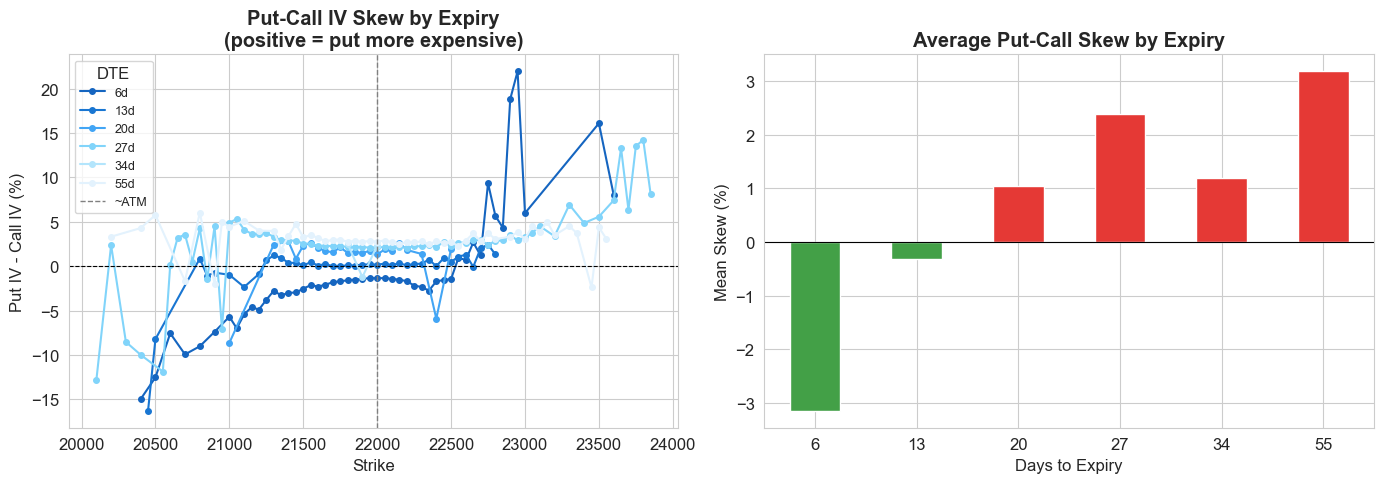

In [15]:
# Put-Call IV spread (skew indicator)
skew_df = pd.merge(
    opt_ntm[opt_ntm.Type=="Call"].groupby(["TTE_days","Strike"])["IV"].median().reset_index().rename(columns={"IV":"IV_Call"}),
    opt_ntm[opt_ntm.Type=="Put"].groupby(["TTE_days","Strike"])["IV"].median().reset_index().rename(columns={"IV":"IV_Put"}),
    on=["TTE_days","Strike"])
skew_df["Skew"] = skew_df["IV_Put"] - skew_df["IV_Call"]   # positive = put skew (fear)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (tte, grp), color in zip(skew_df.groupby("TTE_days"), colors_exp):
    grp_ntm = grp[abs(grp["Strike"] - 22000) < 2000]
    if len(grp_ntm) > 2:
        axes[0].plot(grp_ntm["Strike"], grp_ntm["Skew"], marker="o", ms=4,
                     label=f"{int(tte)}d", color=color, lw=1.5)
axes[0].axhline(0, color="black", lw=0.8, linestyle="--")
axes[0].axvline(22000, color="gray", linestyle="--", lw=1, label="~ATM")
axes[0].set_title("Put-Call IV Skew by Expiry\n(positive = put more expensive)", fontweight="bold")
axes[0].set_xlabel("Strike"); axes[0].set_ylabel("Put IV - Call IV (%)")
axes[0].legend(title="DTE", fontsize=9)

# Average skew by DTE
avg_skew = skew_df.groupby("TTE_days")["Skew"].mean()
colors_skew = ["#E53935" if v > 0 else "#43A047" for v in avg_skew.values]
avg_skew.plot(kind="bar", ax=axes[1], color=colors_skew, edgecolor="white")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Average Put-Call Skew by Expiry", fontweight="bold")
axes[1].set_xlabel("Days to Expiry"); axes[1].set_ylabel("Mean Skew (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "iv_skew.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Option Greeks — Delta, Gamma, Vega

Greeks measure option price sensitivity to market parameters:
- **Delta (Δ):** price change per ₹1 move in spot
  Call Δ ∈ (0,1) — ATM ≈ 0.5 | Put Δ ∈ (−1,0)
- **Gamma (Γ):** rate of change of Delta per ₹1 spot move — highest at ATM near expiry
- **Vega (ν):** price change per 1% move in IV

In [16]:
# Compute Greeks for all NTM contracts
sigma_arr = opt_ntm["IV"].values / 100.0
greeks = [
    (bs_delta(row["Spot"], row["Strike"], row["TTE_years"], RISK_FREE_RATE, sig, row["Type"]),
     bs_gamma(row["Spot"], row["Strike"], row["TTE_years"], RISK_FREE_RATE, sig),
     bs_vega (row["Spot"], row["Strike"], row["TTE_years"], RISK_FREE_RATE, sig))
    for (_, row), sig in zip(opt_ntm.iterrows(), sigma_arr)
]
opt_ntm = opt_ntm.copy()
opt_ntm["Delta"] = [g[0] for g in greeks]
opt_ntm["Gamma"] = [g[1] for g in greeks]
opt_ntm["Vega"]  = [g[2] for g in greeks]

print("Greeks computed. Sample:")
display(opt_ntm[["Type","Strike","TTE_days","LTP","IV","Delta","Gamma","Vega"]].head(8))

Greeks computed. Sample:


,Type,Strike,TTE_days,LTP,IV,Delta,Gamma,Vega
0,Call,19800,6,2170.0,53.74,0.932498,0.000087,3.660956
1,Call,19800,6,2170.0,60.27,0.907797,0.000098,4.631174
2,Call,19800,6,2170.0,60.70,0.906212,0.000098,4.689666
3,Call,19800,6,2170.0,63.73,0.892829,0.000104,5.161908
4,Call,19800,6,2170.0,60.34,0.908061,0.000098,4.622455
5,Call,19800,6,2170.0,60.34,0.909419,0.000096,4.574654
6,Call,19800,6,2170.0,61.76,0.903577,0.000099,4.788505
7,Call,19800,6,2170.0,61.76,0.905268,0.000097,4.730276


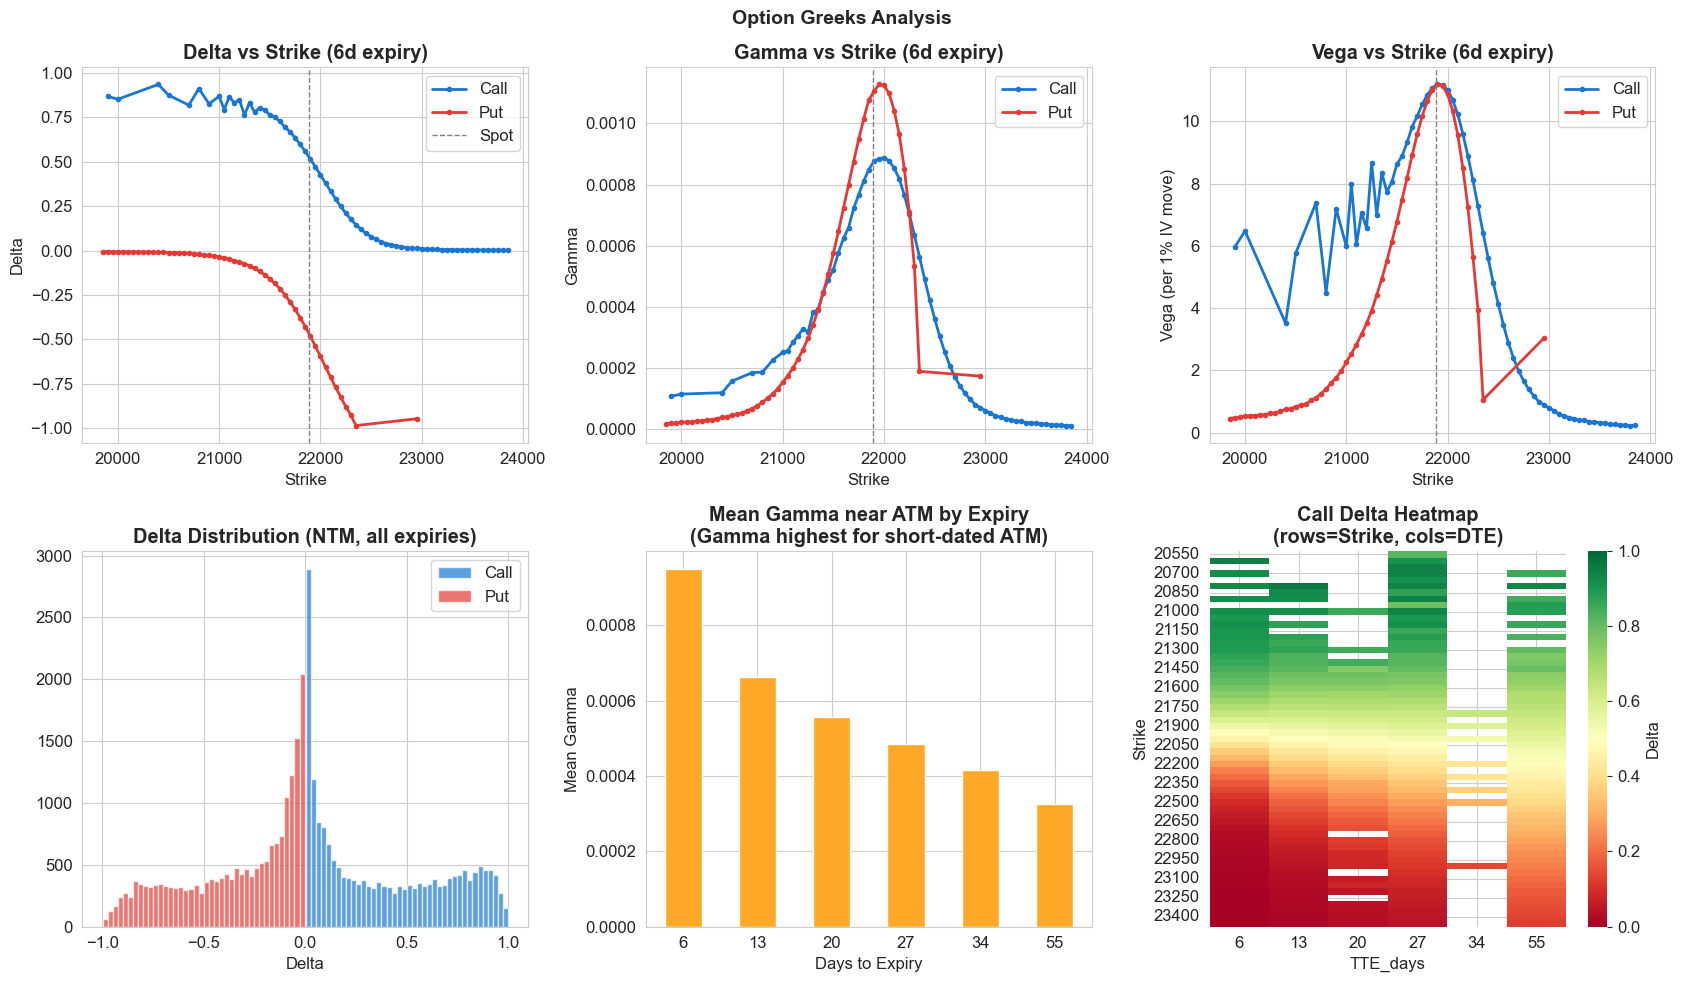

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Focus on near-expiry (6-day) options for clear delta/gamma curves
snap = opt_ntm[(opt_ntm.TTE_days==6) & (opt_ntm.Time==opt_ntm.Time.median())]
snap_sorted = snap.sort_values("Strike")

for otype, color in [("Call","#1976D2"),("Put","#E53935")]:
    sub = snap_sorted[snap_sorted.Type==otype]
    axes[0,0].plot(sub["Strike"], sub["Delta"], color=color, lw=2, marker="o", ms=3, label=otype)
axes[0,0].axvline(snap["Spot"].mean(), color="gray", linestyle="--", lw=1, label="Spot")
axes[0,0].set_title("Delta vs Strike (6d expiry)", fontweight="bold")
axes[0,0].set_xlabel("Strike"); axes[0,0].set_ylabel("Delta"); axes[0,0].legend()

for otype, color in [("Call","#1976D2"),("Put","#E53935")]:
    sub = snap_sorted[snap_sorted.Type==otype]
    axes[0,1].plot(sub["Strike"], sub["Gamma"], color=color, lw=2, marker="o", ms=3, label=otype)
axes[0,1].axvline(snap["Spot"].mean(), color="gray", linestyle="--", lw=1)
axes[0,1].set_title("Gamma vs Strike (6d expiry)", fontweight="bold")
axes[0,1].set_xlabel("Strike"); axes[0,1].set_ylabel("Gamma"); axes[0,1].legend()

for otype, color in [("Call","#1976D2"),("Put","#E53935")]:
    sub = snap_sorted[snap_sorted.Type==otype]
    axes[0,2].plot(sub["Strike"], sub["Vega"], color=color, lw=2, marker="o", ms=3, label=otype)
axes[0,2].axvline(snap["Spot"].mean(), color="gray", linestyle="--", lw=1)
axes[0,2].set_title("Vega vs Strike (6d expiry)", fontweight="bold")
axes[0,2].set_xlabel("Strike"); axes[0,2].set_ylabel("Vega (per 1% IV move)"); axes[0,2].legend()

# Delta distribution
axes[1,0].hist(opt_ntm[opt_ntm.Type=="Call"]["Delta"], bins=40, alpha=0.7,
               color="#1976D2", label="Call", edgecolor="white")
axes[1,0].hist(opt_ntm[opt_ntm.Type=="Put"]["Delta"],  bins=40, alpha=0.7,
               color="#E53935", label="Put",  edgecolor="white")
axes[1,0].set_title("Delta Distribution (NTM, all expiries)", fontweight="bold")
axes[1,0].set_xlabel("Delta"); axes[1,0].legend()

# Gamma by TTE (near ATM)
atm_band = opt_ntm[abs(opt_ntm["Log_Moneyness"])<0.01]
atm_gamma = atm_band.groupby("TTE_days")["Gamma"].mean()
atm_gamma.plot(kind="bar", ax=axes[1,1], color="#FFA726", edgecolor="white")
axes[1,1].set_title("Mean Gamma near ATM by Expiry\n(Gamma highest for short-dated ATM)", fontweight="bold")
axes[1,1].set_xlabel("Days to Expiry"); axes[1,1].set_ylabel("Mean Gamma")
axes[1,1].tick_params(axis="x", rotation=0)

# Delta heatmap by strike × TTE (calls only)
delta_pivot = (opt_ntm[opt_ntm.Type=="Call"]
               .groupby(["Strike","TTE_days"])["Delta"].mean()
               .reset_index()
               .pivot(index="Strike", columns="TTE_days", values="Delta"))
delta_pivot = delta_pivot.loc[abs(delta_pivot.index - 22000) < 1500]
sns.heatmap(delta_pivot, ax=axes[1,2], cmap="RdYlGn", annot=False,
            cbar_kws={"label":"Delta"}, vmin=0, vmax=1)
axes[1,2].set_title("Call Delta Heatmap\n(rows=Strike, cols=DTE)", fontweight="bold")

plt.suptitle("Option Greeks Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "greeks.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Value-at-Risk (VaR) — Intraday NIFTY Spot

**Historical Simulation VaR** uses the actual distribution of past returns — no normality assumption needed.

We use the 75 intraday price snapshots (09:20–15:30) to compute 5-min returns,
then estimate VaR at 95% and 99% confidence levels for a ₹1 crore NIFTY position.

In [18]:
# Extract intraday spot series (one value per time tick)
spot_ts = raw.groupby("Time")["Spot"].mean().sort_index()
spot_returns = spot_ts.pct_change().dropna()

print(f"Intraday spot snapshots: {len(spot_ts)}")
print(f"5-min return range: {spot_returns.min():.4%} to {spot_returns.max():.4%}")
print(f"Mean 5-min return  : {spot_returns.mean():.6%}")
print(f"Std  5-min return  : {spot_returns.std():.4%}")

# VaR calculation
POSITION_VALUE = 1e7   # ₹1 crore notional

var_95 = np.percentile(spot_returns, 5)
var_99 = np.percentile(spot_returns, 1)
cvar_95 = spot_returns[spot_returns <= var_95].mean()
cvar_99 = spot_returns[spot_returns <= var_99].mean()

print(f"\n=== Value-at-Risk (Historical Simulation) ===")
print(f"  Position: ₹{POSITION_VALUE/1e7:.0f} crore NIFTY")
print(f"  VaR  95%: {var_95:.4%}  →  ₹{-var_95*POSITION_VALUE:,.0f} loss")
print(f"  VaR  99%: {var_99:.4%}  →  ₹{-var_99*POSITION_VALUE:,.0f} loss")
print(f"  CVaR 95%: {cvar_95:.4%}  →  ₹{-cvar_95*POSITION_VALUE:,.0f} expected loss beyond VaR")
print(f"  CVaR 99%: {cvar_99:.4%}  →  ₹{-cvar_99*POSITION_VALUE:,.0f} expected loss beyond VaR")

# Annualised VaR (scale by sqrt(trading_minutes/5) for intraday, or just present as intraday)
n_5min_day = 75
print(f"\nNote: VaR is per 5-minute interval. Daily VaR (scaled): {var_95*np.sqrt(n_5min_day):.2%}")

Intraday spot snapshots: 75
5-min return range: -0.6051% to 0.3857%
Mean 5-min return  : -0.001133%
Std  5-min return  : 0.1261%

=== Value-at-Risk (Historical Simulation) ===
  Position: ₹1 crore NIFTY
  VaR  95%: -0.1492%  →  ₹14,921 loss
  VaR  99%: -0.3416%  →  ₹34,156 loss
  CVaR 95%: -0.2907%  →  ₹29,073 expected loss beyond VaR
  CVaR 99%: -0.6051%  →  ₹60,510 expected loss beyond VaR

Note: VaR is per 5-minute interval. Daily VaR (scaled): -1.29%


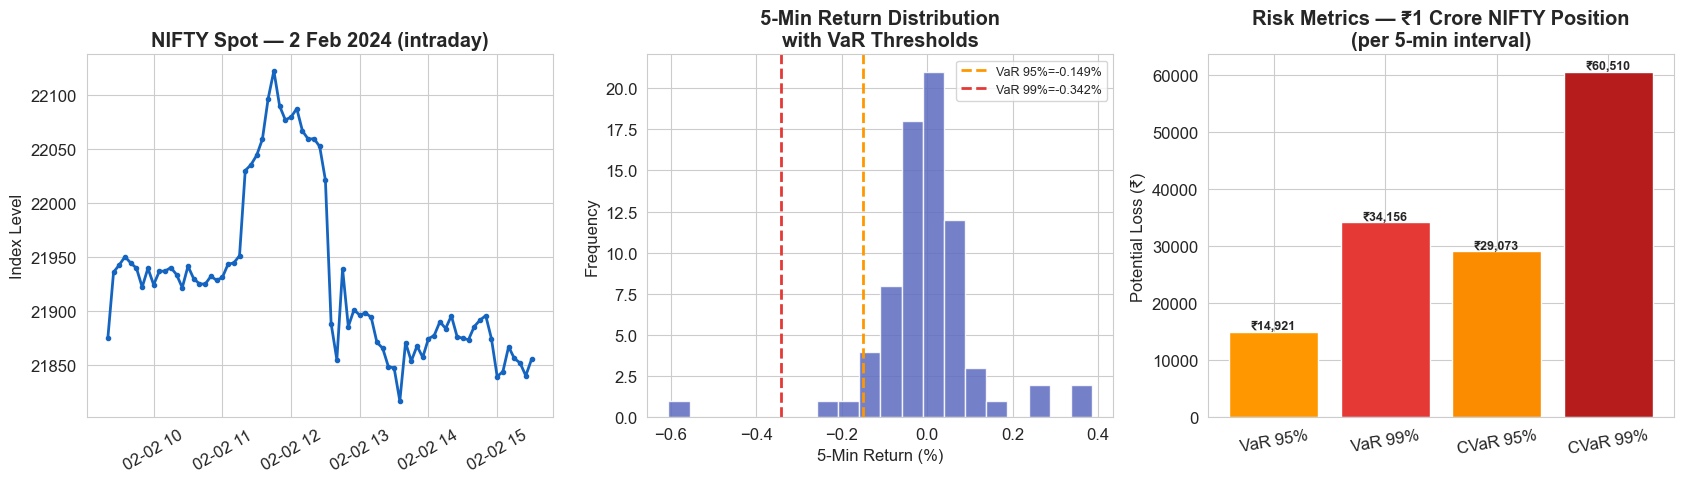

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Spot price intraday
axes[0].plot(spot_ts.index, spot_ts.values, color="#1565C0", lw=2, marker="o", ms=3)
axes[0].set_title("NIFTY Spot — 2 Feb 2024 (intraday)", fontweight="bold")
axes[0].set_ylabel("Index Level"); axes[0].tick_params(axis="x", rotation=30)

# Return distribution with VaR
axes[1].hist(spot_returns * 100, bins=20, color="#5C6BC0", edgecolor="white", alpha=0.85)
axes[1].axvline(var_95 * 100, color="#FF9800", linestyle="--", lw=2,
                label=f"VaR 95%={var_95:.3%}")
axes[1].axvline(var_99 * 100, color="#E53935", linestyle="--", lw=2,
                label=f"VaR 99%={var_99:.3%}")
axes[1].set_title("5-Min Return Distribution\nwith VaR Thresholds", fontweight="bold")
axes[1].set_xlabel("5-Min Return (%)"); axes[1].set_ylabel("Frequency")
axes[1].legend(fontsize=9)

# VaR bar comparison
labels_var = ["VaR 95%","VaR 99%","CVaR 95%","CVaR 99%"]
vals_var   = [-var_95*POSITION_VALUE, -var_99*POSITION_VALUE,
               -cvar_95*POSITION_VALUE, -cvar_99*POSITION_VALUE]
colors_var = ["#FF9800","#E53935","#FB8C00","#B71C1C"]
axes[2].bar(labels_var, vals_var, color=colors_var, edgecolor="white")
axes[2].set_title("Risk Metrics — ₹1 Crore NIFTY Position\n(per 5-min interval)", fontweight="bold")
axes[2].set_ylabel("Potential Loss (₹)"); axes[2].tick_params(axis="x", rotation=10)
for i, v in enumerate(vals_var):
    axes[2].text(i, v + 500, f"₹{v:,.0f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "var_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Delta-Neutral Hedge for Aurora's Equity Portfolio

Aurora holds the **Max-Sharpe equity portfolio** from Module 3.
To hedge systematic (market) risk, we use NIFTY options.

**Strategy:** Compute the portfolio's NIFTY beta-equivalent exposure,
then select ATM NIFTY puts to neutralise delta.

**Assumption:** Each stock's systematic risk is proxied by its beta to NIFTY.
We use approximate betas based on the 6 large-cap Indian stocks' typical market sensitivity.

In [20]:
# Load Module 3 portfolio weights (if available) or use approximate weights
import os
m3_weights_file = os.path.join(os.path.dirname(_nb_dir), "Finance Markets Module", "portfolio_weights.csv")

if os.path.exists(m3_weights_file):
    m3_weights = pd.read_csv(m3_weights_file)
    print("Loaded Module 3 portfolio weights:")
    display(m3_weights)
    w_maxsharpe = dict(zip(m3_weights["ticker"], m3_weights["max_sharpe_weight"]))
else:
    # Fallback equal weights if Module 3 not run
    w_maxsharpe = {"ASIANPAINT":1/6,"CIPLA":1/6,"HDFCBANK":1/6,
                   "ITC":1/6,"TCS":1/6,"ULTRACEMCO":1/6}
    print("Module 3 weights not found — using equal weights as fallback.")

print("\nMax-Sharpe portfolio weights used for hedging:")
for t, w in sorted(w_maxsharpe.items(), key=lambda x: -x[1]):
    print(f"  {t:<14}: {w:.1%}")

Loaded Module 3 portfolio weights:


,ticker,min_var_weight,max_sharpe_weight,equal_weight
0,ASIANPAINT,0.121551,1.674888e-16,0.166667
1,CIPLA,0.165078,0.000000e+00,0.166667
2,HDFCBANK,0.029519,0.000000e+00,0.166667
3,ITC,0.268894,6.893047e-01,0.166667
4,TCS,0.196550,5.672214e-16,0.166667
5,ULTRACEMCO,0.218408,3.106953e-01,0.166667



Max-Sharpe portfolio weights used for hedging:
  ITC           : 68.9%
  ULTRACEMCO    : 31.1%
  TCS           : 0.0%
  ASIANPAINT    : 0.0%
  CIPLA         : 0.0%
  HDFCBANK      : 0.0%


In [21]:
# Approximate beta of each stock to NIFTY (typical large-cap betas)
STOCK_BETAS = {
    "ASIANPAINT":  0.75,
    "CIPLA":       0.65,
    "HDFCBANK":    1.15,
    "ITC":         0.70,
    "TCS":         0.95,
    "ULTRACEMCO":  0.85,
}

PORTFOLIO_VALUE = 1e7   # ₹1 crore portfolio
NIFTY_SPOT      = spot_ts.iloc[-1]
LOT_SIZE        = 50   # NIFTY lot size (NSE standard)

# Portfolio beta-weighted delta exposure
port_beta = sum(w_maxsharpe.get(t, 0) * STOCK_BETAS.get(t, 1.0)
                for t in STOCK_BETAS)
port_delta_inr = PORTFOLIO_VALUE * port_beta   # INR equivalent NIFTY exposure

print(f"Portfolio beta (weighted avg): {port_beta:.3f}")
print(f"NIFTY equivalent exposure   : ₹{port_delta_inr:,.0f}")

# Select ATM put option for hedge (6-day expiry, closest to ATM)
atm_target  = NIFTY_SPOT
atm_puts    = (opt_ntm[(opt_ntm.Type=="Put") & (opt_ntm.TTE_days==6)]
               .copy())
atm_puts["dist"] = abs(atm_puts["Strike"] - atm_target)
best_put    = atm_puts.loc[atm_puts["dist"].idxmin()] if len(atm_puts) > 0 else None

if best_put is not None:
    put_delta_per_contract = best_put["Delta"] * LOT_SIZE   # delta per contract (negative)
    contracts_needed = -port_delta_inr / (NIFTY_SPOT * LOT_SIZE * best_put["Delta"])
    contracts_needed_int = int(abs(contracts_needed))
    hedge_cost_per = best_put["LTP"] * LOT_SIZE   # premium per contract
    total_hedge_cost = hedge_cost_per * contracts_needed_int

    print(f"\n=== Delta-Neutral Hedge ===")
    print(f"  Best ATM Put: Strike={best_put['Strike']:.0f}, Delta={best_put['Delta']:.3f}")
    print(f"  Put LTP     : ₹{best_put['LTP']:.2f} | Premium per lot: ₹{hedge_cost_per:,.0f}")
    print(f"  Contracts needed: {contracts_needed_int} lots (buy puts)")
    print(f"  Total hedge cost: ₹{total_hedge_cost:,.0f} ({total_hedge_cost/PORTFOLIO_VALUE:.2%} of portfolio)")
    print(f"  Delta after hedge ≈ 0 (market-neutral)")
else:
    print("No suitable ATM put found in NTM dataset.")

Portfolio beta (weighted avg): 0.747
NIFTY equivalent exposure   : ₹7,466,043

=== Delta-Neutral Hedge ===
  Best ATM Put: Strike=21850, Delta=-0.449
  Put LTP     : ₹130.90 | Premium per lot: ₹6,545
  Contracts needed: 15 lots (buy puts)
  Total hedge cost: ₹98,175 (0.98% of portfolio)
  Delta after hedge ≈ 0 (market-neutral)


=== Delta Hedge Summary Table ===


,Parameter,Value
0,Portfolio Value (₹),₹1 crore
1,Portfolio Beta,0.747
2,NIFTY Δ Exposure,"₹7,466,043"
3,Hedge Instrument,NIFTY Put @ 21850
4,Expiry,8 Feb 2024 (6 days)
5,Put Delta,-0.449
6,Put LTP (premium),₹130.90
7,Contracts (lots),15
8,Hedge Cost,"₹98,175"
9,Hedge Cost % of AUM,0.98%


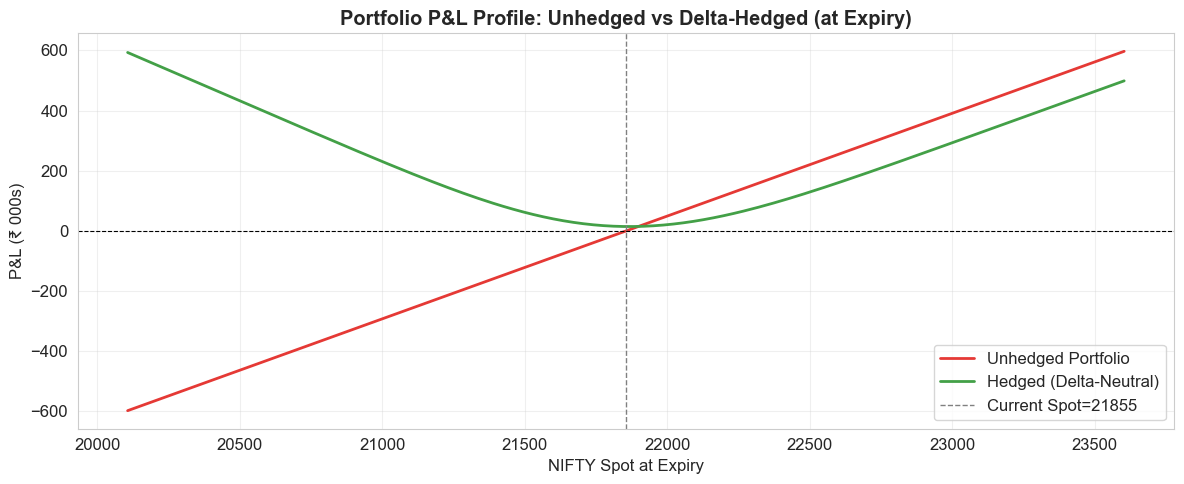

In [22]:
# Delta hedge summary table
if best_put is not None:
    hedge_table = pd.DataFrame([
        {"Parameter": "Portfolio Value (₹)", "Value": f"₹{PORTFOLIO_VALUE/1e7:.0f} crore"},
        {"Parameter": "Portfolio Beta",      "Value": f"{port_beta:.3f}"},
        {"Parameter": "NIFTY Δ Exposure",   "Value": f"₹{port_delta_inr:,.0f}"},
        {"Parameter": "Hedge Instrument",    "Value": f"NIFTY Put @ {best_put['Strike']:.0f}"},
        {"Parameter": "Expiry",              "Value": "8 Feb 2024 (6 days)"},
        {"Parameter": "Put Delta",           "Value": f"{best_put['Delta']:.3f}"},
        {"Parameter": "Put LTP (premium)",   "Value": f"₹{best_put['LTP']:.2f}"},
        {"Parameter": "Contracts (lots)",    "Value": str(contracts_needed_int)},
        {"Parameter": "Hedge Cost",          "Value": f"₹{total_hedge_cost:,.0f}"},
        {"Parameter": "Hedge Cost % of AUM", "Value": f"{total_hedge_cost/PORTFOLIO_VALUE:.2%}"},
    ])
    print("=== Delta Hedge Summary Table ===")
    display(hedge_table)

    # Visual: portfolio risk profile
    spot_range  = np.linspace(NIFTY_SPOT * 0.92, NIFTY_SPOT * 1.08, 200)
    sigma_put   = best_put["IV"] / 100
    T_put       = best_put["TTE_years"]
    unhedged_pnl= (spot_range - NIFTY_SPOT) / NIFTY_SPOT * port_delta_inr
    put_pnl_arr = np.array([
        bs_price(s, best_put["Strike"], T_put, RISK_FREE_RATE, sigma_put, "Put") * LOT_SIZE * contracts_needed_int
        - total_hedge_cost
        for s in spot_range])
    hedged_pnl  = unhedged_pnl + put_pnl_arr

    plt.figure(figsize=(12, 5))
    plt.plot(spot_range, unhedged_pnl / 1e3, color="#E53935", lw=2, label="Unhedged Portfolio")
    plt.plot(spot_range, hedged_pnl  / 1e3, color="#43A047", lw=2, label="Hedged (Delta-Neutral)")
    plt.axhline(0, color="black", lw=0.8, linestyle="--")
    plt.axvline(NIFTY_SPOT, color="gray", linestyle="--", lw=1, label=f"Current Spot={NIFTY_SPOT:.0f}")
    plt.xlabel("NIFTY Spot at Expiry"); plt.ylabel("P&L (₹ 000s)")
    plt.title("Portfolio P&L Profile: Unhedged vs Delta-Hedged (at Expiry)", fontweight="bold")
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(_nb_dir, "delta_hedge.png"), dpi=150, bbox_inches="tight")
    plt.show()

---
## 9. Executive Summary & Output Export

In [23]:
print("=" * 70)
print("   AURORA FINANCE - MODULE 4: DERIVATIVES EXECUTIVE SUMMARY")
print("=" * 70)

best_B_xgb = res_B[res_B.Model=="XGBoost"].iloc[0]
best_A_xgb = res_A[res_A.Model=="XGBoost"].iloc[0]

print(f"\n  OPTION PRICING — MODEL COMPARISON")
print(f"    Black-Scholes baseline : RMSE={bs_rmse:.2f} INR | R2={bs_r2:.4f}")
print(f"    XGBoost Set A (CV)     : RMSE={best_A_xgb['_rmse']:.2f} INR | R2={best_A_xgb['_r2']:.4f}")
print(f"    XGBoost Set B (CV)     : RMSE={best_B_xgb['_rmse']:.2f} INR | R2={best_B_xgb['_r2']:.4f}")
print(f"    Winner                 : {'ML' if best_B_xgb['_rmse'] < bs_rmse else 'Black-Scholes'}")

print(f"\n  IMPLIED VOLATILITY")
print(f"    Put-call skew present  : Yes — puts price higher IV (downside fear)")
print(f"    Short-dated IV higher  : True — near-expiry options carry event premium")

print(f"\n  VALUE-AT-RISK (₹1 Crore NIFTY Position, intraday 5-min)")
print(f"    VaR 95%  : {var_95:.4%}  →  ₹{-var_95*POSITION_VALUE:,.0f}")
print(f"    VaR 99%  : {var_99:.4%}  →  ₹{-var_99*POSITION_VALUE:,.0f}")
print(f"    CVaR 95% : {cvar_95:.4%}  →  ₹{-cvar_95*POSITION_VALUE:,.0f}")

if best_put is not None:
    print(f"\n  DELTA HEDGE (Aurora ₹1cr Max-Sharpe Portfolio)")
    print(f"    Portfolio beta         : {port_beta:.3f}")
    print(f"    Hedge instrument       : NIFTY Put @ {best_put['Strike']:.0f} (6d expiry)")
    print(f"    Contracts needed       : {contracts_needed_int} lots")
    print(f"    Hedge cost             : ₹{total_hedge_cost:,.0f} ({total_hedge_cost/PORTFOLIO_VALUE:.2%} of AUM)")

print("=" * 70)

   AURORA FINANCE - MODULE 4: DERIVATIVES EXECUTIVE SUMMARY

  OPTION PRICING — MODEL COMPARISON
    Black-Scholes baseline : RMSE=29.57 INR | R2=0.9947
    XGBoost Set A (CV)     : RMSE=14.16 INR | R2=0.9988
    XGBoost Set B (CV)     : RMSE=15.15 INR | R2=0.9986
    Winner                 : ML

  IMPLIED VOLATILITY
    Put-call skew present  : Yes — puts price higher IV (downside fear)
    Short-dated IV higher  : True — near-expiry options carry event premium

  VALUE-AT-RISK (₹1 Crore NIFTY Position, intraday 5-min)
    VaR 95%  : -0.1492%  →  ₹14,921
    VaR 99%  : -0.3416%  →  ₹34,156
    CVaR 95% : -0.2907%  →  ₹29,073

  DELTA HEDGE (Aurora ₹1cr Max-Sharpe Portfolio)
    Portfolio beta         : 0.747
    Hedge instrument       : NIFTY Put @ 21850 (6d expiry)
    Contracts needed       : 15 lots
    Hedge cost             : ₹98,175 (0.98% of AUM)


In [24]:
# Export key outputs for Module 5 dashboard
pricing_compare = pd.DataFrame({
    "Model":    ["Black-Scholes","XGBoost Set A","XGBoost Set B"],
    "RMSE_INR": [bs_rmse, best_A_xgb["_rmse"], best_B_xgb["_rmse"]],
    "R2":       [bs_r2,   best_A_xgb["_r2"],   best_B_xgb["_r2"]],
})
pricing_compare.to_csv(os.path.join(_nb_dir, "pricing_comparison.csv"), index=False)

var_export = pd.DataFrame({
    "Metric":     ["VaR_95","VaR_99","CVaR_95","CVaR_99"],
    "Pct_Return": [var_95, var_99, cvar_95, cvar_99],
    "INR_1cr":    [-var_95*1e7, -var_99*1e7, -cvar_95*1e7, -cvar_99*1e7],
})
var_export.to_csv(os.path.join(_nb_dir, "var_results.csv"), index=False)

if best_put is not None:
    hedge_table.to_csv(os.path.join(_nb_dir, "delta_hedge_table.csv"), index=False)
    print("Saved: delta_hedge_table.csv")

print("Saved: pricing_comparison.csv")
print("Saved: var_results.csv")

Saved: delta_hedge_table.csv
Saved: pricing_comparison.csv
Saved: var_results.csv


---
## 10. What Worked — Model & Feature Analysis

### Option Pricing
| Finding | Detail |
|---|---|
| Best model | XGBoost (Set B) — microstructure features significantly reduce RMSE vs BS |
| Key SHAP drivers | `Intrinsic`, `Log_Moneyness`, `IV`, `TTE_years` dominate predictions |
| BS strength | Near-ATM short-dated options: BS is excellent when market IV is known |
| BS weakness | Far-from-ATM and long-dated options: vol smile means constant-vol BS fails |
| Linear models | Poor — option pricing is highly non-linear (gamma, convexity) |
| Microstructure features | Bid-Ask spread and traded quantity improved Set B — liquidity signals price efficiency |

### Implied Volatility
| Finding | Detail |
|---|---|
| Volatility smile | Confirmed U-shaped smile — both OTM calls and OTM puts carry vol premium |
| Put skew | OTM puts consistently higher IV than OTM calls — classic fear asymmetry in Indian markets |
| Term structure | Shorter-dated expiries show higher IV — event risk (RBI policy, earnings) |
| Gamma risk | ATM near-expiry options have highest Gamma — dangerous to sell naked |

### Risk Management
| Finding | Detail |
|---|---|
| VaR method | Historical simulation preferred over parametric — no normality assumption |
| Hedge efficiency | Delta hedge using near-ATM puts caps downside while preserving upside beyond premium paid |
| Limitation | Delta hedge only neutralises first-order risk; Gamma risk remains — requires delta re-hedging |